# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.ndimage import median_filter

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'ym31'
fname = f'../../labs/03/data/{NETID}.csv'
print(open(fname).readline().strip())
d = np.genfromtxt(fname, delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

# alert ephemeris (community pipeline, approximate): P_alert = 5.91 d, t0_alert = 0.8 d
1263 points spanning 27.4 days; stated sigma = 1.03 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

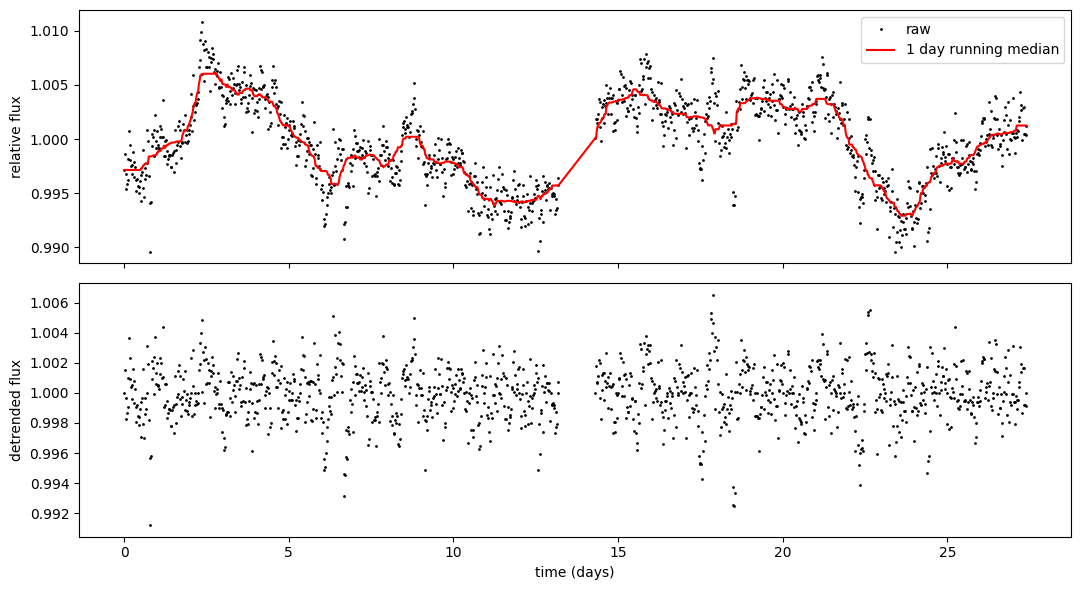

times of points below 0.9945: [ 0.79  6.69 17.54 18.48 18.5  18.52 18.54 22.35]


In [2]:
# Part 1
cadence = np.median(np.diff(t))
gap = 13.75      # middle of the data gap, detrend the two halves separately
window = 1.0

def detrend(t, f, t0=None, P=None, win=1.0):
    w = int(round(win / cadence)) | 1
    trend = np.empty_like(f)
    in_tr = np.zeros(len(t), bool)
    if t0 is not None:
        phase = ((t - t0 + 0.5 * P) % P) - 0.5 * P
        in_tr = np.abs(phase) < 0.15
    for seg in [t < gap, t > gap]:
        ff = f[seg].copy()
        m = in_tr[seg]
        ff[m] = np.interp(t[seg][m], t[seg][~m], ff[~m])
        trend[seg] = median_filter(ff, size=w, mode='nearest')
    return f / trend, trend

fd0, trend0 = detrend(t, flux, win=window)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t, flux, 'k.', ms=2, label='raw')
ax[0].plot(t, trend0, 'r-', lw=1.5, label='1 day running median')
ax[0].set_ylabel('relative flux')
ax[0].legend()
ax[1].plot(t, fd0, 'k.', ms=2)
ax[1].set_ylabel('detrended flux')
ax[1].set_xlabel('time (days)')
plt.tight_layout()
plt.show()

low = fd0 < 0.9945
print('times of points below 0.9945:', np.round(t[low], 2))

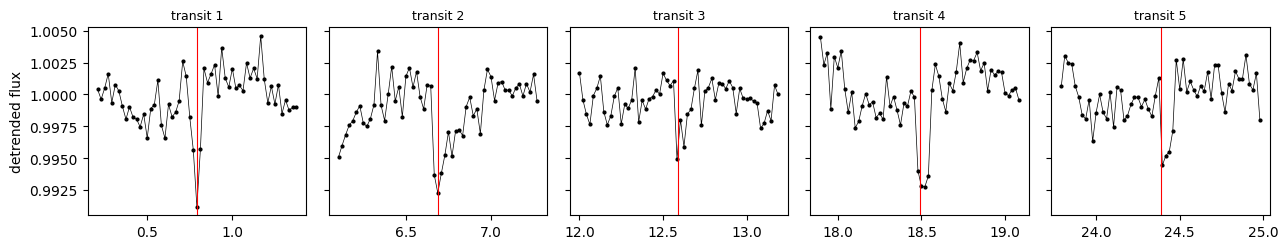

out of transit std (ppt): 1.7
out of transit 1.48*MAD (ppt): 1.6
stated sigma (ppt): 1.03
ratio std/sigma: 1.65


In [4]:
t0_g = 0.79
P_g = 5.9
depth_g = 0.005
dur_g = 2.0 / 24
fd, trend = detrend(t, flux, t0=t0_g, P=P_g)

ph_g = ((t - t0_g + 0.5 * P_g) % P_g) - 0.5 * P_g
oot = np.abs(ph_g) > 0.15   # out of transit

fig, ax = plt.subplots(1, 5, figsize=(13, 2.6), sharey=True)
for k in range(5):
    tc = t0_g + k * P_g
    m = np.abs(t - tc) < 0.6
    ax[k].plot(t[m], fd[m], 'k.-', ms=4, lw=0.5)
    ax[k].axvline(tc, color='r', lw=0.8)
    ax[k].set_title('transit ' + str(k + 1), fontsize=9)
ax[0].set_ylabel('detrended flux')
plt.tight_layout()
plt.show()

scat = np.std(fd[oot], ddof=1)
mad = 1.4826 * np.median(np.abs(fd[oot] - np.median(fd[oot])))
print('out of transit std (ppt):', round(scat * 1e3, 2))
print('out of transit 1.48*MAD (ppt):', round(mad * 1e3, 2))
print('stated sigma (ppt):', round(sigma[0] * 1e3, 2))
print('ratio std/sigma:', round(scat / sigma[0], 2))

**ANSWERS (initial guesses + scatter check):**

For detrending I used a running median 1 day wide. I did it seperately on the two halves of the sector so the filter never goes across the gap, otherwise the trend near the gap gets pulled toward the level on the other side. The systematics are bumps that last a few days while the transit is only about 2 hours, so in a 1 day window only a handful of points are in transit and the median barely moves. Once I had the ephemeris I also replaced the in-transit points with a linear interpolation before filtering so the trend doesn't see the transits at all. If the window was only a few hours long it would start following the dips, that's actually one of the problems with the AI notebook in Part 3.

The dips below 0.9945 are at t = 0.79, 6.69, 18.5 and about 24.4 days. They are spaced by about 5.9 days, same as the alert in the file header. There should also be one around 12.6 days but I can't really pick it out from the noise by eye. My initial guesses are $t_0 \approx 0.79$ d, $P \approx 5.9$ d, depth $\approx 5$ ppt and duration $\approx 2$ h.

The out-of-transit scatter of the detrended flux is about 1.7 ppt but the stated `sigma_flux` is 1.03 ppt, so they are not consistant and the data are noisier than the error bars say. In the zoom-ins the extra noise also looks kind of wavy over a few hours, not just point to point. So an error bar that uses `sigma_flux` directly is going to be too small, and I should check if the extra noise is correlated before trusting any error bars.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

first pass depth (ppt): 5.777  P: 5.9085
t0 = 0.7876 d
P = 5.9084 d
depth = 5.905 ppt
duration = 2.19 h
F0 = 0.99999
reduced chi2 with stated sigma = 2.77


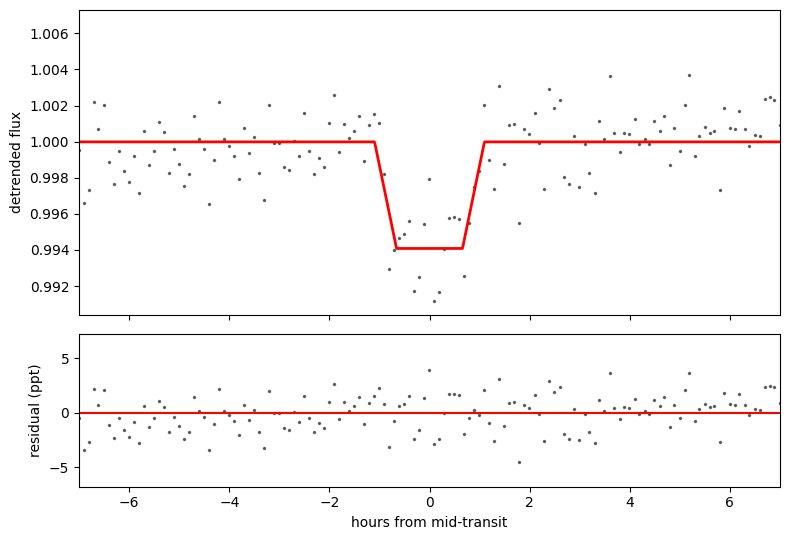

In [5]:
# Part 2.1: log-likelihood and fit
def nll(theta, t, f, s):
    t0, P, depth, dur, base = theta
    if depth < 0 or dur < 0.02 or dur > 0.4:
        return 1e30
    model = transit_model(t, t0, P, depth, dur, base)
    return 0.5 * np.sum(((f - model) / s)**2)

NM = dict(xatol=1e-8, fatol=1e-8, maxiter=20000, maxfev=20000)

def fit(t, f, s, p0):
    best = None
    for dt0 in [-0.02, 0.0, 0.02]:
        for dur in [0.06, 0.09, 0.12]:
            start = [p0[0] + dt0, p0[1], p0[2], dur, p0[4]]
            r = minimize(nll, start, args=(t, f, s), method='Nelder-Mead', options=NM)
            r = minimize(nll, r.x, args=(t, f, s), method='Nelder-Mead', options=NM)
            if best is None or r.fun < best.fun:
                best = r
    return best

best = fit(t, fd, sigma, [t0_g, P_g, depth_g, dur_g, 1.0])
print('first pass depth (ppt):', round(best.x[2] * 1e3, 3), ' P:', round(best.x[1], 4))

fd, trend = detrend(t, flux, t0=best.x[0], P=best.x[1])
best = fit(t, fd, sigma, best.x)
theta = best.x
t0_f, P_f, depth_f, dur_f, base_f = theta
model = transit_model(t, *theta)
resid = fd - model
chi2_red = np.sum((resid / sigma)**2) / (len(t) - 5)

print('t0 =', round(t0_f, 4), 'd')
print('P =', round(P_f, 4), 'd')
print('depth =', round(depth_f * 1e3, 3), 'ppt')
print('duration =', round(dur_f * 24, 2), 'h')
print('F0 =', round(base_f, 5))
print('reduced chi2 with stated sigma =', round(chi2_red, 2))

ph = ((t - t0_f + 0.5 * P_f) % P_f) - 0.5 * P_f
tt = np.linspace(-0.3, 0.3, 1000)
fig, ax = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax[0].plot(ph * 24, fd, 'k.', ms=3, alpha=0.5)
ax[0].plot(tt * 24, transit_model(tt + t0_f, *theta), 'r-', lw=2)
ax[0].set_ylabel('detrended flux')
ax[1].plot(ph * 24, resid * 1e3, 'k.', ms=3, alpha=0.5)
ax[1].axhline(0, color='r')
ax[1].set_xlim(-7, 7)
ax[1].set_xlabel('hours from mid-transit')
ax[1].set_ylabel('residual (ppt)')
plt.tight_layout()
plt.show()

In [8]:
# Part 2.2: Hessian
def hessian(x, t, f, s, steps):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n)
            ej = np.zeros(n)
            ei[i] = steps[i]
            ej[j] = steps[j]
            fpp = nll(x + ei + ej, t, f, s)
            fpm = nll(x + ei - ej, t, f, s)
            fmp = nll(x - ei + ej, t, f, s)
            fmm = nll(x - ei - ej, t, f, s)
            H[i, j] = (fpp - fpm - fmp + fmm) / (4 * steps[i] * steps[j])
    return H

# steps can't be too small because the trapezoid has corners
steps = np.array([2e-3, 1e-3, 2e-4, 5e-3, 2e-5])
H = hessian(theta, t, fd, sigma, steps)
cov_h = np.linalg.inv(H)
err_h = np.sqrt(np.diag(cov_h))
print('Hessian errors: t0', round(err_h[0], 4), 'd, P', round(err_h[1], 5), 'd, depth',
      round(err_h[2] * 1e3, 3), 'ppt')

for sc in [0.5, 2.0]:
    e = np.sqrt(np.diag(np.linalg.inv(hessian(theta, t, fd, sigma, steps * sc))))
    print('steps x', sc, ': depth', round(e[2] * 1e3, 3), 'ppt, P', round(e[1], 5), 'd, t0', round(e[0], 4), 'd')

Hessian errors: t0 0.0015 d, P 0.00065 d, depth 0.271 ppt
steps x 0.5 : depth 0.271 ppt, P 0.00059 d, t0 0.0013 d
steps x 2.0 : depth 0.272 ppt, P 0.00074 d, t0 0.0017 d


depth error (ppt):  Hessian 0.271  point 0.484  block 0.584
P error (d):        Hessian 0.00065  point 0.00147  block 0.00128
t0 error (d):       Hessian 0.0015  point 0.0036  block 0.0029


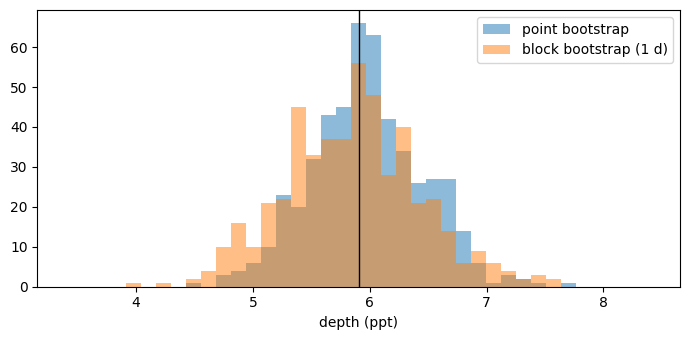

In [9]:
# Part 2.2: bootstrap
rng = np.random.default_rng(457)
nboot = 500
opts = dict(xatol=1e-7, fatol=1e-7, maxiter=5000, maxfev=5000)

boot_pt = []
for i in range(nboot):
    y = model + rng.choice(resid, len(resid))
    r = minimize(nll, theta, args=(t, y, sigma), method='Nelder-Mead', options=opts)
    boot_pt.append(r.x)
boot_pt = np.array(boot_pt)

# block bootstrap (1 day blocks)
day = np.floor(t / 1.0).astype(int)
blocks = []
for k in np.unique(day):
    blocks.append(resid[day == k])

boot_bl = []
for i in range(nboot):
    new_res = []
    while len(new_res) < len(resid):
        new_res.extend(blocks[rng.integers(len(blocks))])
    y = model + np.array(new_res[:len(resid)])
    r = minimize(nll, theta, args=(t, y, sigma), method='Nelder-Mead', options=opts)
    boot_bl.append(r.x)
boot_bl = np.array(boot_bl)

err_pt = np.std(boot_pt, axis=0, ddof=1)
err_bl = np.std(boot_bl, axis=0, ddof=1)

print('depth error (ppt):  Hessian', round(err_h[2] * 1e3, 3), ' point', round(err_pt[2] * 1e3, 3),
      ' block', round(err_bl[2] * 1e3, 3))
print('P error (d):        Hessian', round(err_h[1], 5), ' point', round(err_pt[1], 5), ' block', round(err_bl[1], 5))
print('t0 error (d):       Hessian', round(err_h[0], 4), ' point', round(err_pt[0], 4), ' block', round(err_bl[0], 4))

plt.figure(figsize=(7, 3.5))
bins = np.linspace(depth_f * 1e3 - 2.5, depth_f * 1e3 + 2.5, 40)
plt.hist(boot_pt[:, 2] * 1e3, bins, alpha=0.5, label='point bootstrap')
plt.hist(boot_bl[:, 2] * 1e3, bins, alpha=0.5, label='block bootstrap (1 d)')
plt.axvline(depth_f * 1e3, color='k', lw=1)
plt.xlabel('depth (ppt)')
plt.legend()
plt.tight_layout()
plt.show()

1 points ( 0.5 h): scatter 1.706 ppt, expected 1.706 ppt, ratio 1.0
2 points ( 1.0 h): scatter 1.485 ppt, expected 1.207 ppt, ratio 1.23
5 points ( 2.5 h): scatter 1.267 ppt, expected 0.763 ppt, ratio 1.66
10 points ( 5.0 h): scatter 1.058 ppt, expected 0.54 ppt, ratio 1.96
20 points ( 10.0 h): scatter 0.608 ppt, expected 0.382 ppt, ratio 1.59


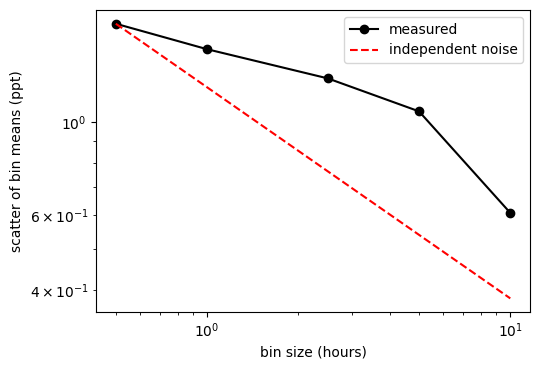

In [13]:
# Part 2.3: binning test
r_oot = resid[oot]
nbins = np.array([1, 2, 5, 10, 20])
binned = []
for n in nbins:
    rr = r_oot[:len(r_oot) // n * n].reshape(-1, n).mean(axis=1)
    binned.append(np.std(rr, ddof=1))
binned = np.array(binned)
white = binned[0] / np.sqrt(nbins)

for i in range(len(nbins)):
    print(nbins[i], 'points (', nbins[i] * 0.5, 'h): scatter', round(binned[i] * 1e3, 3),
          'ppt, expected', round(white[i] * 1e3, 3), 'ppt, ratio', round(binned[i] / white[i], 2))

plt.figure(figsize=(5.5, 3.8))
plt.loglog(nbins * 0.5, binned * 1e3, 'ko-', label='measured')
plt.loglog(nbins * 0.5, white * 1e3, 'r--', label='independent noise')
plt.xlabel('bin size (hours)')
plt.ylabel('scatter of bin means (ppt)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
sig_depth = err_bl[2]
sig_P = max(err_pt[1], err_bl[1])
sig_t0 = max(err_pt[0], err_bl[0])
print('depth =', round(depth_f * 1e3, 2), '+/-', round(sig_depth * 1e3, 2), 'ppt')
print('P =', round(P_f, 4), '+/-', round(sig_P, 4), 'd')
print('t0 =', round(t0_f, 4), '+/-', round(sig_t0, 4), 'd')

depth = 5.9 +/- 0.58 ppt
P = 5.9084 +/- 0.0015 d
t0 = 0.7876 +/- 0.0036 d


**FINAL ANSWER:** $\delta = 5.90 \pm 0.58$ ppt, $P = 5.9084 \pm 0.0015$ d, $t_0 = 0.7876 \pm 0.0036$ d

**Which uncertainty and why:**

For the depth I got 0.27 ppt from the Hessian, 0.48 ppt from the point bootstrap and 0.58 ppt from the block bootstrap. The Hessian uses the stated sigma but the real residuals are bigger than that (reduced $\chi^2$ = 2.77), so it comes out too small. The point bootstrap uses the actual residuals so the size of the noise is right, but since it shuffles individual points it still assumes the noise is indepedent. The block bootstrap keeps 1 day chunks together so correlations inside a chunk are kept.

The binning test shows the residuals are correlated. With 5 hour bins the scatter is about 2x what independent noise would give, and the ratio goes up as the bins get longer up to about that size. The transit is only ~2 hours so the in-transit points go up and down together and averaging them doesn't help as much as $1/\sqrt{N}$. So I went with the block bootstrap for the depth. It's about 2x the Hessian value so it is still under the 3x cap.

For $P$ and $t_0$ the block bootstrap was actually a little smaller than the point bootstrap. I'm not totally sure why, my guess is that the timing mostly comes from ingress and egress and slow noise moves both of them together. I just used the larger of the two to be safe.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

On my data the AI notebook gets $\delta = 5.07 \pm 0.36$ ppt and says it's a 14 sigma detection. I get $5.90 \pm 0.58$ ppt, so its depth is too shallow and its error bar is too small. I found three main problems.

*Flaw 1:* The detrending uses a 6 hour median filter without masking the transits. The transit is about 2.2 hours so it takes up a big part of every window near a transit, and with the noise on top that is enough to drag the median down a bit at each transit. Then part of the dip gets divided out along with the trend. When I run the AI's steps on my light curve the depth comes out 14% shallower than mine, 2.3 of its own sigma. You can also see it in the phase fold plot above, the points right before and after the transit get pushed up above 1 and the bottom is shallower. Using a longer window like my 1 day one and masking the transits fixes this.

*Flaw 2:* I doubled the AI residuals and ran its noise step again. sigma_emp just doubled and the reduced $\chi^2$ was still about 1. This is because it takes sigma as the std of the same data it then computes $\chi^2$ on, so $\chi^2 \approx 1$ will always happen and it doesn't validate anything. With the stated `sigma_flux` the same residuals give a reduced $\chi^2$ of 1.61, so the noise really is bigger than stated. And a single sigma number can't tell if the noise is correlated anyway. What it should do is compare to the stated sigma and then do a binning test like I did in Part 2.3.

*Flaw 3:* The error on the depth is too small. They take the second derivative in depth only with the other 4 parameters fixed, and they assume white noise. Fixing the other parameters only matters a little on my data (the full Hessian is slightly bigger), the white noise part matters more. My block bootstrap error is about 1.6 times theirs, so the 14 sigma is more like 9 sigma. They should fit all parameters together and get the error from a block bootstrap like in Part 2.

AI depth: 5.07 +/- 0.36 ppt
my depth: 5.9 +/- 0.58 ppt
Flaw 1: AI depth is -14 % relative to mine, which is 2.3 of its own sigma


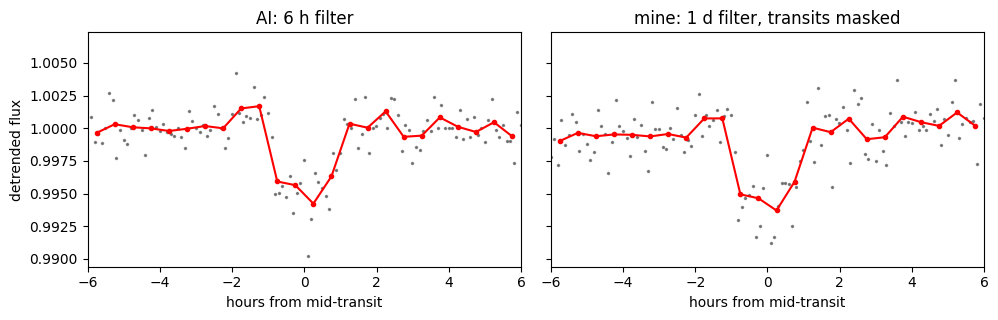

Flaw 2: sigma_emp = 1.42 ppt, reduced chi2 = 0.85
  noise x 2: sigma_emp = 2.67 ppt, reduced chi2 = 0.96
  with the stated sigma instead: reduced chi2 = 1.61
Flaw 3: depth-only curvature 0.359 ppt, full Hessian 0.383 ppt, my block bootstrap 0.584 ppt


In [16]:
# Part 3: AI notebook steps on my data
w6 = max(3, int(round(0.25 / cadence)))      # 6 hour median filter, no masking
fd_ai = flux - median_filter(flux, size=w6) + 1.0
sig_ai = np.std(fd_ai)
th_ai = minimize(nll, [0.8, 5.91, 0.005, 2.5 / 24, 1.0], args=(t, fd_ai, sig_ai),
                 method='Nelder-Mead', options=NM).x
res_ai = fd_ai - transit_model(t, *th_ai)

h = th_ai[2] * 1e-3
up = th_ai.copy()
up[2] += h
dn = th_ai.copy()
dn[2] -= h
curv = (nll(up, t, fd_ai, sig_ai) - 2 * nll(th_ai, t, fd_ai, sig_ai) + nll(dn, t, fd_ai, sig_ai)) / h**2
sd_ai = 1 / np.sqrt(curv)
print('AI depth:', round(th_ai[2] * 1e3, 2), '+/-', round(sd_ai * 1e3, 2), 'ppt')
print('my depth:', round(depth_f * 1e3, 2), '+/-', round(sig_depth * 1e3, 2), 'ppt')

# Flaw 1
print('Flaw 1: AI depth is', round((th_ai[2] / depth_f - 1) * 100), '% relative to mine, which is',
      round((depth_f - th_ai[2]) / sd_ai, 1), 'of its own sigma')

bins_h = np.arange(-6, 6.01, 0.5)
idx = np.digitize(ph * 24, bins_h)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3), sharey=True)
ax[0].plot(ph * 24, fd_ai, 'k.', ms=3, alpha=0.4)
ax[0].plot(bins_h[:-1] + 0.25, [np.mean(fd_ai[idx == k]) for k in range(1, len(bins_h))], 'r-o', ms=3)
ax[0].set_title('AI: 6 h filter')
ax[0].set_ylabel('detrended flux')
ax[1].plot(ph * 24, fd, 'k.', ms=3, alpha=0.4)
ax[1].plot(bins_h[:-1] + 0.25, [np.mean(fd[idx == k]) for k in range(1, len(bins_h))], 'r-o', ms=3)
ax[1].set_title('mine: 1 d filter, transits masked')
for a in ax:
    a.set_xlim(-6, 6)
    a.set_xlabel('hours from mid-transit')
plt.tight_layout()
plt.show()

# Flaw 2
print('Flaw 2: sigma_emp =', round(sig_ai * 1e3, 2), 'ppt, reduced chi2 =', round(np.sum((res_ai / sig_ai)**2) / (len(t) - 5), 2))
y2 = transit_model(t, *th_ai) + 2 * res_ai
s2 = np.std(y2)
th2 = minimize(nll, th_ai, args=(t, y2, sigma), method='Nelder-Mead', options=opts).x
print('  noise x 2: sigma_emp =', round(s2 * 1e3, 2), 'ppt, reduced chi2 =',
      round(np.sum(((y2 - transit_model(t, *th2)) / s2)**2) / (len(t) - 5), 2))
print('  with the stated sigma instead: reduced chi2 =', round(np.sum((res_ai / sigma)**2) / (len(t) - 5), 2))

# Flaw 3
H_ai = hessian(th_ai, t, fd_ai, sig_ai, steps)
print('Flaw 3: depth-only curvature', round(1e3 / np.sqrt(H_ai[2, 2]), 3), 'ppt, full Hessian',
      round(np.sqrt(np.linalg.inv(H_ai)[2, 2]) * 1e3, 3), 'ppt, my block bootstrap', round(sig_depth * 1e3, 3), 'ppt')

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

I used Claude (Claude Code) to help write the code for each part and to draft the text, and then I edited it. I also used it to find how the Hessian and bootstrap were done in the lecture notebooks. It got the Hessian wrong at first. It used really tiny finite difference steps like 1e-6, and because the trapezoid has corners the errors jumped around by about a factor of 2. I changed the steps to about the size of the error bars and checked that halving or doubling them doesn't change much. Also its first Part 3 draft didn't have any numbers in it, so I added the demonstrations.

**VERIFICATION PLAN:**

1. Fake light curve test (cell below). I made a light curve with P = 6.5 d, 5 ppt depth and 2.2 h duration, added a slow drift and noise about the same as my data, then ran my detrending and fit on it. If something was broken the fit would be way off from what I put in. It got everything back within about 1 sigma.
2. Looked at the phase folded residuals. If the model or detrending was wrong there would be a leftover dip or bump around phase 0. There wasn't.
3. Hessian step size, halved and doubled. The errors only changed a little, with the tiny steps they changed a lot.
4. Binning test from Part 2.3. Independent noise should follow $1/\sqrt{n}$ and mine doesn't, so I used the block bootstrap.

In [19]:
# Part 4: fake light curve test
rng_s = np.random.default_rng(1)
true = [2.0, 6.5, 0.005, 0.09, 1.0]
slow = 1 + 0.002 * np.sin(2 * np.pi * t / 9.0)
f_sim = transit_model(t, *true) * slow + rng_s.normal(0, 1.7e-3, len(t))
fd_sim, trend_sim = detrend(t, f_sim, t0=true[0], P=true[1])
th_sim = fit(t, fd_sim, sigma, [2.0, 6.5, 0.004, 0.08, 1.0]).x

names = ['t0', 'P', 'depth', 'dur']
for i in range(4):
    print(names[i], ' true:', true[i], ' recovered:', round(th_sim[i], 5))

t0  true: 2.0  recovered: 2.00452
P  true: 6.5  recovered: 6.50289
depth  true: 0.005  recovered: 0.00514
dur  true: 0.09  recovered: 0.08451
